In [1]:
# ─────────────────────────────────────────────────────────────
# CELL 1 — Imports and Connections
# ─────────────────────────────────────────────────────────────

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import requests
from catboost import CatBoostRegressor
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

In [2]:
# ─────────────────────────────────────────────────────────────
# CELL 2 — Load Local Inverter Data from CSV
# ─────────────────────────────────────────────────────────────

# Update path to where your CSV is saved on your laptop
csv_path = "D:\Desktop\ESSCO\essco-ai\Dataset\TKKHEAD01\semply_cloud.meter.solar.1.csv" 

df_inverter = pd.read_csv(csv_path)

# 1. Standardize column mapping (Ensuring 'timestamp' and 'ac_power_total')
# If your CSV uses a different timestamp column name (like 'time' or 'date'), update it on the right side below:
df_inverter = df_inverter.rename(columns={
    "dateTime": "timestamp",   # Replace "time" if your column name is different
    "pTot": "ac_power_total"
})

# 2. Keep only required columns and remove missing records
keep_cols = ["timestamp", "ac_power_total"]
df_inverter = df_inverter[keep_cols].dropna(subset=["ac_power_total"])

print(f"✅ Inverter CSV data loaded → shape: {df_inverter.shape}")
print(f"   Date range: {df_inverter['timestamp'].min()}  →  {df_inverter['timestamp'].max()}\n")
df_inverter.head(3)

✅ Inverter CSV data loaded → shape: (316922, 2)
   Date range: 2025-11-08T03:46:23.000Z  →  2026-06-19T12:54:01.000Z



,timestamp,ac_power_total
0,2026-06-19T12:54:01.000Z,23.20
1,2026-06-19T12:53:01.000Z,17.22
2,2026-06-19T12:52:01.000Z,22.10


In [3]:
# ─────────────────────────────────────────────────────────────
# CELL 3 — Fetch Weather Data via Open-Meteo API
# ─────────────────────────────────────────────────────────────
import pandas as pd
import requests

# 1. Automatically match the time range of your historical CSV
start_date = pd.to_datetime(df_inverter['timestamp'].min()).strftime('%Y-%m-%d')
end_date = pd.to_datetime(df_inverter['timestamp'].max()).strftime('%Y-%m-%d')

# 2. Configure Open-Meteo API parameters (Using Historical Forecast API for 15-min intervals)
latitude = 13.7275   
longitude = 100.7781 

# FIXED: Changed from 'archive-api' to 'historical-forecast-api' to support minutely_15
url = "https://historical-forecast-api.open-meteo.com/v1/forecast"
params = {
    "latitude": latitude,
    "longitude": longitude,
    "start_date": start_date,
    "end_date": end_date,
    "minutely_15": "direct_radiation",
    "timezone": "UTC"
}

print(f"🌐 Fetching Open-Meteo historical 15-min weather from {start_date} to {end_date}...")
response = requests.get(url, params=params).json()

# Check if the API returned an error to prevent silent script crashes
if "error" in response:
    raise ValueError(f"Open-Meteo API Error: {response['reason']}")

# 3. Parse 15-minute data into your traditional df_weather format
minutely_data = response["minutely_15"]

df_weather = pd.DataFrame({
    "timestamp": minutely_data["time"],
    "solar_irradiance": minutely_data["direct_radiation"],  # Mapped to your old feature name
})

# Clean and drop any missing records
df_weather = df_weather.dropna(subset=["solar_irradiance"])

print(f"✅ Open-Meteo Weather data loaded → shape: {df_weather.shape}")
print(f"   Date range: {df_weather['timestamp'].min()}  →  {df_weather['timestamp'].max()}")
df_weather.head(3)

🌐 Fetching Open-Meteo historical 15-min weather from 2025-11-08 to 2026-06-19...
✅ Open-Meteo Weather data loaded → shape: (21504, 2)
   Date range: 2025-11-08T00:00  →  2026-06-19T23:45


,timestamp,solar_irradiance
0,2025-11-08T00:00,7.0
1,2025-11-08T00:15,16.0
2,2025-11-08T00:30,28.0


In [4]:
# ─────────────────────────────────────────────────────────────
# CELL 5 — Resample All Sources to 5-Minute Grid
# ─────────────────────────────────────────────────────────────

def to_utc_index(df: pd.DataFrame, ts_col: str = "timestamp") -> pd.DataFrame:
    """Convert a timestamp column to a UTC-aware DatetimeIndex."""
    df = df.copy()
    df[ts_col] = pd.to_datetime(df[ts_col])
    if df[ts_col].dt.tz is None:
        df[ts_col] = df[ts_col].dt.tz_localize("UTC")
    else:
        df[ts_col] = df[ts_col].dt.tz_convert("UTC")
    df = df.set_index(ts_col).sort_index()
    return df

# ── 1. Inverter (CSV) — 5-min mean from 'pTot' ─────────────────
df_inverter = to_utc_index(df_inverter)
df_inverter = df_inverter.resample("5min").mean()
print(f"✅ df_inverter  resampled → {df_inverter.shape}")

# ── 2. Weather (Keep or skip if also embedded in your CSV) ─────
df_weather = to_utc_index(df_weather)
df_weather = df_weather.resample("5min").mean().interpolate(method="time")
print(f"✅ df_weather   resampled → {df_weather.shape}")

print("\n📋 All sources aligned to 5-minute UTC grid")

✅ df_inverter  resampled → (64334, 1)
✅ df_weather   resampled → (64510, 1)

📋 All sources aligned to 5-minute UTC grid


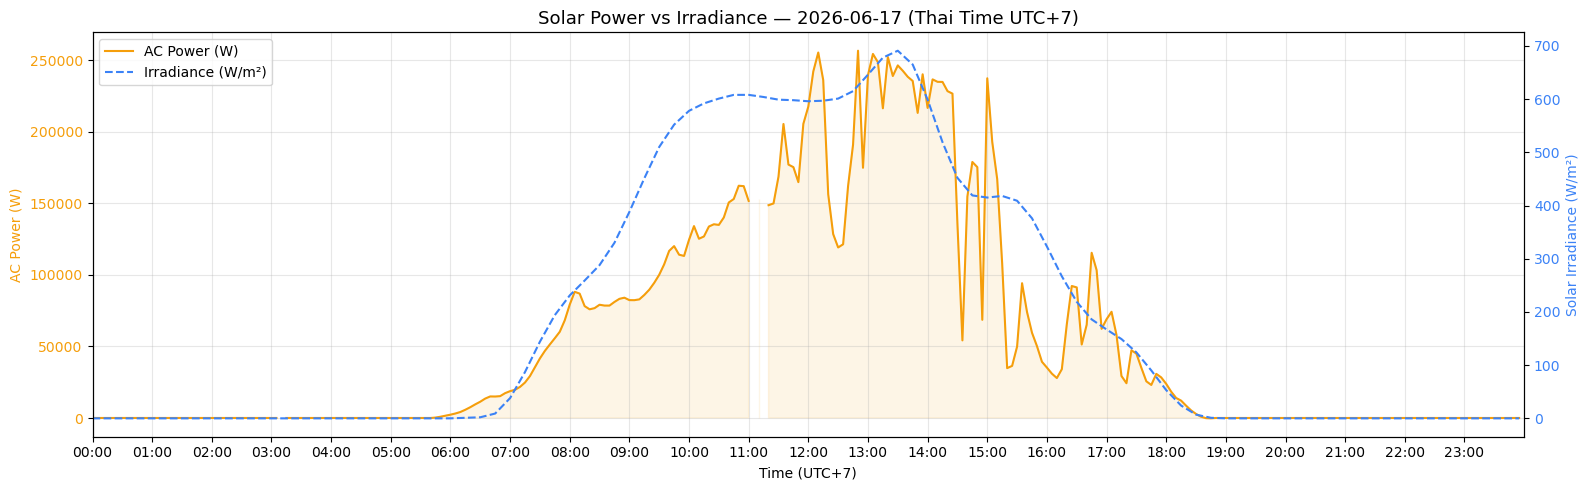

In [5]:
# ─────────────────────────────────────────────────────────────
# CELL 6 — Plot Solar Power vs Irradiance (Single Day)
# ─────────────────────────────────────────────────────────────

TARGET_DATE = "2026-06-17"  # ← change to any date

day_start = pd.Timestamp(TARGET_DATE + " 00:00:00", tz="Asia/Bangkok")
day_end   = pd.Timestamp(TARGET_DATE + " 23:59:59", tz="Asia/Bangkok")

# Convert UTC index → Thai time for filtering
inv_thai   = df_inverter.copy()
inv_thai.index = inv_thai.index.tz_convert("Asia/Bangkok")

wx_thai    = df_weather.copy()
wx_thai.index = wx_thai.index.tz_convert("Asia/Bangkok")

# Filter to target day
inv_day = inv_thai[(inv_thai.index >= day_start) & (inv_thai.index <= day_end)]
wx_day  = wx_thai[(wx_thai.index >= day_start)  & (wx_thai.index <= day_end)]

# Strip tz for matplotlib
inv_times = inv_day.index.tz_localize(None)
wx_times  = wx_day.index.tz_localize(None)

xlim_start = pd.Timestamp(TARGET_DATE + " 00:00:00")
xlim_end   = pd.Timestamp(TARGET_DATE + " 23:59:59")

# ── Dual-axis plot ──────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(16, 5))

# Left axis — AC Power
ax1.plot(inv_times, inv_day["ac_power_total"],
         color="#f59e0b", linewidth=1.5, label="AC Power (W)")
ax1.fill_between(inv_times, inv_day["ac_power_total"],
                 alpha=0.10, color="#f59e0b")
ax1.set_ylabel("AC Power (W)", color="#f59e0b")
ax1.tick_params(axis="y", labelcolor="#f59e0b")

# Right axis — Solar Irradiance
ax2 = ax1.twinx()
ax2.plot(wx_times, wx_day["solar_irradiance"],
         color="#3b82f6", linewidth=1.5, linestyle="--", label="Irradiance (W/m²)")
ax2.set_ylabel("Solar Irradiance (W/m²)", color="#3b82f6")
ax2.tick_params(axis="y", labelcolor="#3b82f6")

# X-axis
ax1.set_xlim(xlim_start, xlim_end)
ax1.xaxis.set_major_locator(mdates.HourLocator(interval=1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.xticks(rotation=45)

# Legend — combine both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

ax1.set_title(f"Solar Power vs Irradiance — {TARGET_DATE} (Thai Time UTC+7)", fontsize=13)
ax1.set_xlabel("Time (UTC+7)")
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()